# Running INCInERATOr on a Kepler Target


In this tutorial, we will learn how to use `incinerator`!


## Step 1: Imports

First, make sure you are running the notebook in the **correct environment** (if you created one). Your Python kernel should be set to that environment.

Next, import `incinerator` and a few other useful packages.

In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits

import incinerator.localize as loc

%matplotlib inline

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


## Step 2: Initialize Localize Object

##### **NOTE:** `incinerator` only deals with **1 quarter/sector** of data at a time for the moment!

### **Get Your File**

For this tutorial, we will use the Quarter 1 target pixel file (TPF) for **Kepler-8 (KIC 6922244)**.  

> ⚠️ Important: `incinerator` requires a **local file** when using **Kepler or TESS TPFs**, because it relies on information in the `.fits` header.

You have two options:

**1. Download manually**  

You can download the TPF from [MAST Kepler Search](https://archive.stsci.edu/kepler/data_search/search.php).

**2. Download using `astroquery`**

You will need to add the following to your imports:

```python
from astroquery.mast import Observations

In [2]:
#you can find the file in the tutorials/` folder inside the `docs/` directory on GitHub.
file_path = "kplr006922244-2009166043257_lpd-targ.fits"
#opening the file
hdu = fits.open(file_path)

#extracting time, flux cube (in this case a tpf), and flux cube error
time = hdu[1].data['TIME']
flux = hdu[1].data['FLUX']
flux_err = hdu[1].data['FLUX_ERR']

### **Load Your TCEs**

You will also need the information for the **Threshold Crossing Events (TCEs)**.  

You have two options:

**1. Read from a CSV file**

**2. Create a pandas DataFrame manually**

**Note:** Kepler-8 only has **one TCE**, but if your target has **multiple TCEs**, you can simply add each of them as a **row in the same DataFrame**.  

**Important:** Make sure the columns are in the order expected by the function:

- `period` → **1st column**  
- *(any other column you may have)*  
- `t0` → **3rd column**  
- `tdur` → **4th column** (best rounded to **two significant figures** and in **units of days**)

**Why?** Because that’s how `incinerator` reads the TCEs internally, and the function relies on this ordering.


In [3]:
#creating tce dataframe
tces = pd.DataFrame({'star_id':6922244.01,
                     'period':3.5224,
                     'mes':np.nan,
                     't0':121.1194228,
                     'tdur':.12},index=[0])

### **Initialize the Localize Object**

Now it’s time to **create a `Localize` object**!  

You will need to provide the following inputs:

- `time` → the time array from your TPF  
- `flux` → the flux values  
- `flux_err` → the flux uncertainties  
- `tces` → the TCEs DataFrame we just created  
- `id` → the target’s KIC or TIC number  
- `mission` → `"kepler"` or `"tess"` depending on your TPF  
- `file_path` → the path to the TPF file  

> **Optional:** If you are analyzing a **background star in the TPF**, you can also include **bonus RA and DEC**.

See the API for more details.

In [4]:
#initialize you Localize class object
loc_obj = loc.Localize(time, flux, flux_err, tces.to_numpy(), '6922244',
                       mission='kepler', file_name = file_path)

## Step 3: Build the Design Matrix

Now we get to the easier part: running the necessary functions.

We need to **build the design matrix**, which incorporates all of the TCEs in your DataFrame.

In [5]:
#build the design matrix
loc_obj.build_design_matrix()

## Step 4: Generate Heatmaps and Fit PRF

### **Solve for the transits**

First, we solve for the **weights of each transit component** in the design matrix. 

If your target has multiple TCEs, they are **solved simultaneously**.

In [6]:
#solve for the weights of the transit components
loc_obj.solve_transit_weights()

/Users/jmoquin/mypy/incinerator/src/incinerator/localize.py:392: RuntimeWarning: invalid value encountered in sqrt
  self.weights_err[idx] = np.sqrt(np.diag(np.linalg.inv(sigma_w_inv)))


### **Fit PRF model**


Next, we fit the PRF model to the resulting heat map to determine the likely location of the signal on the CCD. 

If your target has **multiple TCEs**, you have two options:

**1. Fit all TCEs at once**
```python
  which_tce = None
```

**2. Fit one TCE at a time**
```python
  which_tce = <index of the TCE>
```

In [7]:
#fit prf to heatmap
full_report, fit = loc_obj.fit_to_heatmap(method='prf',which_tce=0)
full_report

## Step 5: Visualize Results

### **Plot the results**

/Users/jmoquin/mypy/incinerator/src/incinerator/localize.py:723: RuntimeWarning: Mean of empty slice
  cax1 = axes[1].imshow(np.nanmean(self.flux, axis=0),origin='lower')#, norm=colors.LogNorm())


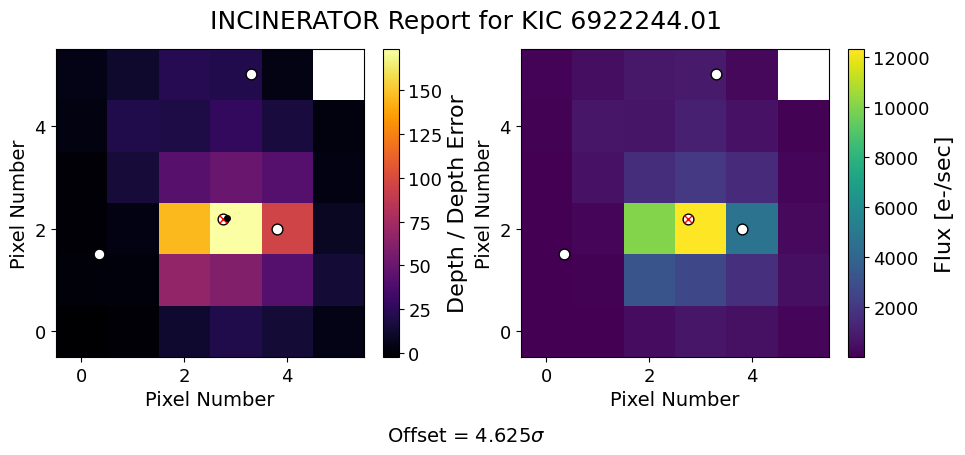

In [8]:
#getting the incinerator report
loc_obj.plot_heatmap(fit,0,savefig=False)

### **Interpreting results**

The output figure contains two panels:

- **Left panel:** The "transit localization" **heatmap**  
  - The **red X** marks the the target star.  
  - The **black dot** shows the fitted location of the transit signal.  
  - Error bars represent the uncertainty in the fitted position.

- **Right panel:** The **Target Pixel File (TPF)**

The **offset** represents the **separation (in units of σ)** between the fitted position and the position of the target star.

If the fitted position is **close to the pixel containing the target star**, this suggests the transit signal is likely originating from that pixel. Larger offsets may indicate that the signal is coming from a **nearby contaminating source** instead.